# PyTorch Workflow
Here we cover a standard PyTorch workflow

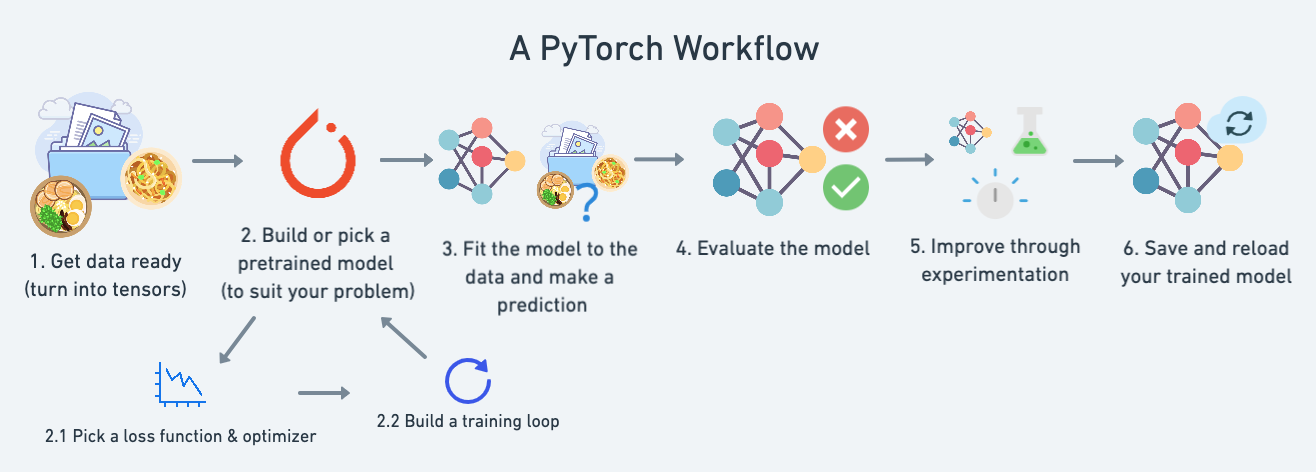

1. Load and prepare the data
2. Build a model
3. Training/Fitting the model to the data 
4. Making predictions and evaluating a model (Inference)
5. Saving and loading the model
6. Putting it all together


In [85]:
import torch
from torch import nn
 # nn contains all building blocks for neural networks
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split

import time

torch.__version__


'2.8.0+cpu'

### Data (Loading & Preparing)
Data can be in any format:
- Excel spreadsheets
- Images of any kind
- Videos
- Audios
- DNA
- Text

Machine learning/deep learning entails two main parts:
1. Get data into a numerical representation that can be used by the model
2. Build the model to learn patterns in that numerical representation

To start off, let's create some *known* data (using the linear regression formula (i.e.- $y = mx + b$ or $\hat{y}= \beta_0 + \beta_1x$)) then use the formula to make a straight line with *known parameters.*

In [86]:
## Known parameters (m, b)
weight= 0.7 # parameter m
bias= 0.3 # parameter b
 # So we know these numbers but we want to create a model to estimate these numbers

## The data (x,y)
start= 0
stop= 1
step= 0.02
X= torch.arange(start, stop, step).unsqueeze(dim=1)
 # Adds an extra dimension as ML models can't work with vectors
 # ML models work with matrices and other higher dimensional tensors
y= weight * X + bias

# First 5 values of input (x) and output (y)
print(f'Shape of x: {X.shape}')
print(f'{X[:5]}')
print('----' * 30)
print(f'Shape of y: {y.shape}')
print(f'{y[:5]}') 


Shape of x: torch.Size([50, 1])
tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800]])
------------------------------------------------------------------------------------------------------------------------
Shape of y: torch.Size([50, 1])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560]])


In the above code we already know the model parameters for $y= mx + b$ where $m$ (the slope) represents the 'weight' and $b$ (the y-intercept) represents the 'bias'. In a real-world scenario, these parameters are unknown and our goal is to create a model that uses the data (x,y) to find them; therefore estimating the relationship between variables x and y (how the input data (x) affects the output data (y)).

Now that we have the data, the next step is to split it prior to using the data to build a model.
- Training set: The model learns from this data (*~60-80%*)
- Validation set: The model is tuned using this data (often used but not always) (*~10-20%*). It is often recommended to use since tuning using the test set may cause data leakage and over-optimistic results during the final model evaluation. Though most times when faced with limited data, this can be skipped.
- Test set: The model is evaluated on this data to check how well it performs on unseen data (*~10-20%*). Note the term *unseen* which means data that the model has never seen before. This data is only used for the final model evaluation. It is not to be used during model training or tuning or as a validation set.

For purposes of simpleicity in this example we will use simple data to train a model then validate with the test set

In [87]:
## Splitting into training and testing set
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, 
                                                   shuffle= True, 
                                                   random_state= 42)

print(f'X_train Shape: {X_train.shape}')
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')


X_train Shape: torch.Size([40, 1])
y_train Shape: torch.Size([40, 1])
X_test Shape: torch.Size([10, 1])
y_test Shape: torch.Size([10, 1])


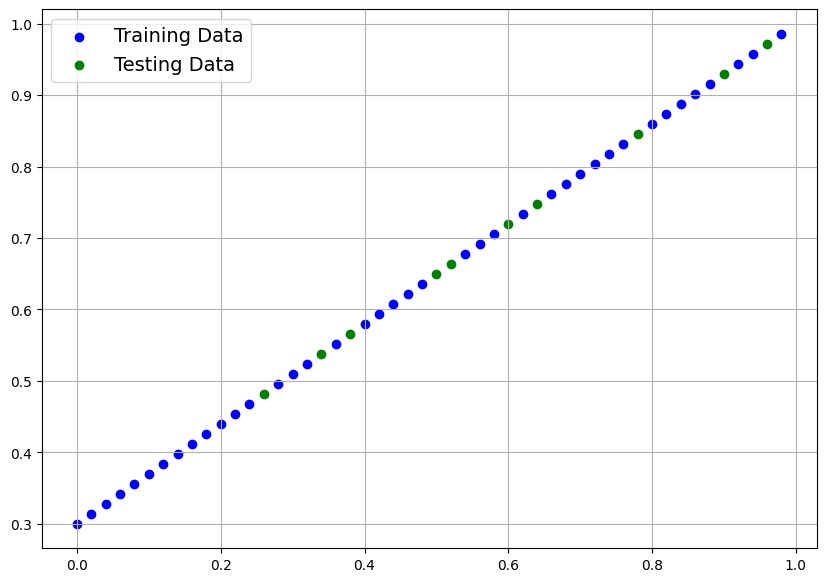

In [88]:
## Visualize the data
def plot_predictions(x_train= X_train,
                     x_test= X_test,
                     y_train= y_train,
                     y_test= y_test,
                     predictions=None # We dont have predictions yet; but could have them later on
                     ): 
    '''
    A function that plots the training data, test data and compares predictions
    '''
    plt.figure(figsize= (10,7))

    # Plot training data
    plt.scatter(X_train, y_train, color= 'blue', label= 'Training Data')

    # Plot testing data
    plt.scatter(x_test, y_test, color= 'green', label= 'Testing Data')

    # Predictions (They are plotted if they exist)
    if predictions is not None:
        plt.scatter(x_test, predictions, color= 'red', label= 'predictions')

    plt.legend(prop= {'size': 14})
    plt.grid()

plot_predictions()



So a machine learning model should learn the pattern of the blue dots (input) and be able to accurately predict the red dots (outputs)

### Buidling a Model

In [89]:
## Building a linear regression model class (Custom function)
# Requires some understanding of Object Oriented Programming in Python
class LinearRegressionModel(nn.Module): # Almost everything is PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weight= nn.Parameter(torch.randn(1, 
                                               requires_grad= True, 
                                               dtype= torch.float32))
         # Here we set the weight value as a random value from a standard normal distribution
         # Requires grad makes the engine (known as autograd in PyTorch) to track all operations in the background
         # This tracking is essential in optimization algorithms, gradient descent, backpropagation, etc
        self.bias= nn.Parameter(torch.randn(1, 
                                               requires_grad= True,
                                               dtype= torch.float32))
         # We also set a random value for bias
## Forward method defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # The `forward` method defines computation across all models
         # This function takes in x (the data which is a tensor) and should output a tensor
        return (self.weight * x) + self.bias
         # Linear regression formula (y= mx + c) or (y= B0 =B1x)
    
        

So the above linear regression model starts with random parameters for `weight` and `bias` in $y= weight \cdot X + bias$ or $y= B_1X + B_0$. Then these parameters should be updated accordingly based on the training data $(X, y)$

Updating of parameters is done via:
- Gradient descent
- Backpropagation

##### NB: PyTorch Model buidling essentials
- `torch.nn`- Contains all the buildings for computational graphs (a neural network can be considered a computational graph) and all the building blocks for deep learning (e.g.- layers, loss functions, etc.)
- `torch.nn.Parameter`- What parameters the model should learn/update, often a PyTorch neural network layer will set these for us
- `torch.nn.Module`- The base class for all neural network modules, if you subclass this you should overwrite the `forward()`
- `torch.optim`- This is where the optimizers in PyTorch are found (algorithms for updating the parameters of the model), such as `torch.optim.SGD` for stochastic gradient descent and `torch.optim.Adam` for Adam optimization.
- All `nn.Module` subclasses require one to overwrite the `forward()` method which defines the computation performed by the model.

Other modules exist and can be applied throughout the PyTorch workflow (e.g- `torch.utils.data.DataLoader` for loading data into a PyTorch model, `torchmetrics` for evaluating models, etc.....)


Recall the Linear Regression model created above. We can check the contents of our model (the model parameters that are being trained) using `.parameters()`

In [90]:
## Random seed for reproducibility
torch.manual_seed(5)

## Instance of the above class LinearRegressionMdel()
model_0= LinearRegressionModel()
print(list(model_0.parameters())) # Output can be shown as a list
print(f'\n{model_0.state_dict()}') # A better way of showing parameter values

## Original weight and bias values
print()
print({"known_weight": weight,
         "known_bias": bias})

[Parameter containing:
tensor([-0.4868], requires_grad=True), Parameter containing:
tensor([-0.6038], requires_grad=True)]

OrderedDict({'weight': tensor([-0.4868]), 'bias': tensor([-0.6038])})

{'known_weight': 0.7, 'known_bias': 0.3}


The closer the Linear Regression model parameter values get to the `known_weight` and `known_bias` the better. 

Making predictions is done using `torch.inference_model()`. We want to check how well the model predicts `y_test` using `x_test` values.

In [91]:
## Data
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: torch.Size([40, 1])
y_train: torch.Size([40, 1])
X_test: torch.Size([10, 1])
y_test: torch.Size([10, 1])


CPU times: total: 0 ns
Wall time: 0 ns
tensor([[-0.7304],
        [-0.9835],
        [-0.8959],
        [-1.0419],
        [-0.7693]])


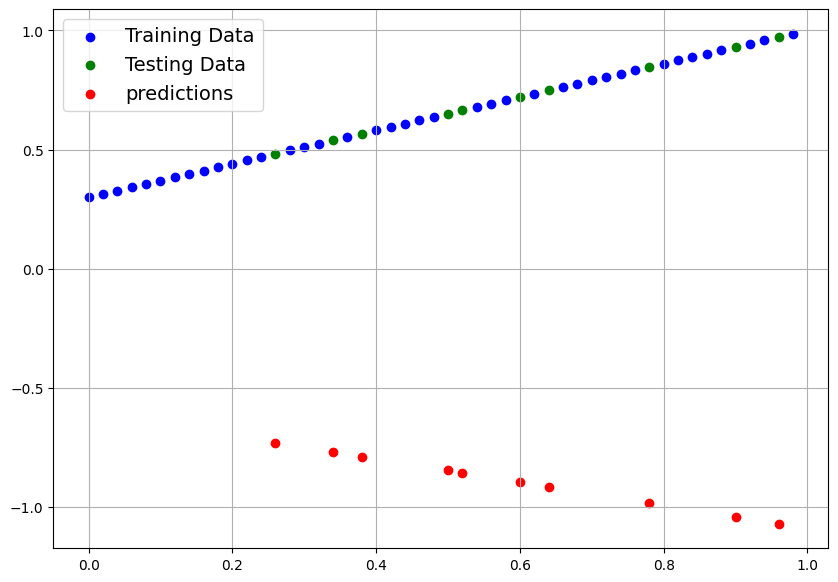

In [92]:
## Making predictions
%time
with torch.inference_mode():
    y_pred= model_0(X_test)
    
## Model predictions
print(y_pred[:5])
plot_predictions(predictions= y_pred)

Model predictions are quite bad initially as we first used random parameters for `weight` and `bias`.

`torch.inference_mode()` is a context manager that disables gradient tracking when `forward()` pass is performed. This is useful for inference/prediction such that the process is faster and uses less memory as gradients are not needed in this stage. 

CPU times: total: 0 ns
Wall time: 0 ns
tensor([[-0.7304],
        [-0.9835],
        [-0.8959],
        [-1.0419],
        [-0.7693]])


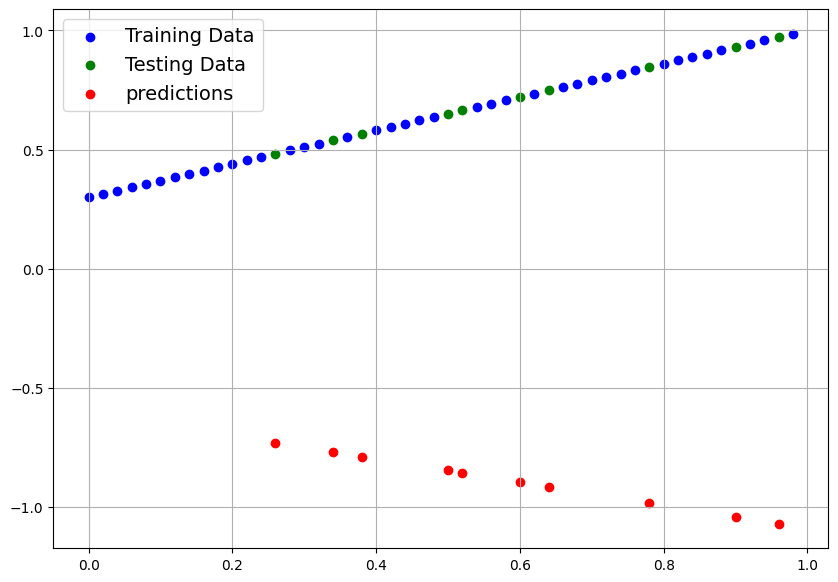

In [93]:
## Making predictions
%time
with torch.inference_mode():
    y_pred_no_inference_mode= model_0(X_test)
    
print(y_pred_no_inference_mode[:5])
plot_predictions(predictions= y_pred_no_inference_mode)

### Training the ML model
So we need to train the ML model where we move from some unknown/random parameters (that are a poor representation of the data) to some known/optimal parameters (that are a better representation of the data). 


One way to measure how poorly the model's predictions may be, we implement a *loss function* (also known as *criterion* or *cost function* in different areas)

The things we need to train for a particular model are:
- A *loss function* is a mathematical formula that quantifies the accuracy of a machine learning model by determining the difference between a model's predicted output and the actual true data.
- An *optimizer* is an algorithm or method that is used to improve the model's performance (i.e. minimize the loss function) by adjusting the model's parameters (i.e.- weights and biases).

In this example, we will use the `nn.L1Loss()` loss function which is simply the Mean Absolute Error (MAE).
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i - y_i|$$
So our goal is to minimize the absolute difference between the predicted and actual values (From the above diagram, the absolute distance between 'predictions' line and the 'testing data' line)

For the optimizer, we use `torch.optim` which is a package thta contains a variety of optimization algorithms (e.g.- Stochastic Gradient Descent, Adam, RMSprop, etc.). Inside the optimizer we set two parameters:
- `params` which consist of the model's parameters (i.e.- weights and biases)
- `lr` which is the learning rate (i.e.- how fast the model should update its parameters). Note that this is a *hyperparameter* (a value that is set by the user and is not learned during training) in comparison to a *parameter* (a value that is learned during training and is part of the model).

The best loss function and optimizer to use are problem specific

In [94]:
## Set up a loss function
loss_fn= nn.L1Loss() # MAE

## Set up an optimizer (adjusts the model's parameters by minimizing loss function)
optimizer= torch.optim.SGD(params= model_0.parameters(), # Model parameters
                           lr= 0.001) # The speed at which the optimizer adjusts model parameters (higher -> larger steps model parameters and vice versa)

##### Constructing a Training (and Testing) Loop in PyTorch
Some things we might need for a training loop:
0. Loop through the data (looking at the data multiple times)
1. Forward pass (this involves data moving through the model's `forward()` function)-- also known as forward propagation
2. Compute the loss (compare forward pass predictons to actual (ground truth) labels)
3. Optimizer zero grad
4. Backward pass/backpropagation (moving backwards through the network to calculate the gradients of each of the parameters of the model with respect to the loss)
5. Optimizer step- use the optimizer to adjust the model's parameters to try and improve the loss

A **gradient** in machine learning is a vector (2D tensor) of partial derivatives of the loss function with respect to each of the model's parameters. It is used by the optimizer determine how much each parameter should be adjusted in order to minimize the loss. Study [Gradient Descent](https://youtu.be/sDv4f4s2SB8?si=1zyHPYRHvfZasTJV) to understand how this partial derivative computation works.

A single training loop through the data is known as an *epoch*. Most models employ multiple epochs (e.g.- $\approx$ 100) when training a model.

Note that when when training parameters, the tensor must be able to account for gradient monitoring (`requires_grad=True`). This is because the optimizer will adjust the parameters in place, and the gradient will be computed with respect to the parameters.

During testing `requires_grad=False` is used as gradient tracking is not needed and also to save on computation time. Set by `torch.infference_mode()`.



In [95]:
list(model_0.parameters())

[Parameter containing:
 tensor([-0.4868], requires_grad=True),
 Parameter containing:
 tensor([-0.6038], requires_grad=True)]

In [96]:
## Model parameter values before the training loop
model_0.state_dict()

OrderedDict([('weight', tensor([-0.4868])), ('bias', tensor([-0.6038]))])

------------------------------------------------------------------------------------------
Epoch 0
Training Loss: 1.456268072128296
Testing Loss: 1.6003748178482056
OrderedDict({'weight': tensor([-0.4863]), 'bias': tensor([-0.6028])})
------------------------------------------------------------------------------------------
Epoch 10
Training Loss: 1.444101095199585
Testing Loss: 1.587638020515442
OrderedDict({'weight': tensor([-0.4817]), 'bias': tensor([-0.5928])})
------------------------------------------------------------------------------------------
Epoch 20
Training Loss: 1.4319343566894531
Testing Loss: 1.5749008655548096
OrderedDict({'weight': tensor([-0.4770]), 'bias': tensor([-0.5828])})
------------------------------------------------------------------------------------------
Epoch 30
Training Loss: 1.4197676181793213
Testing Loss: 1.5621637105941772
OrderedDict({'weight': tensor([-0.4723]), 'bias': tensor([-0.5728])})
--------------------------------------------------------

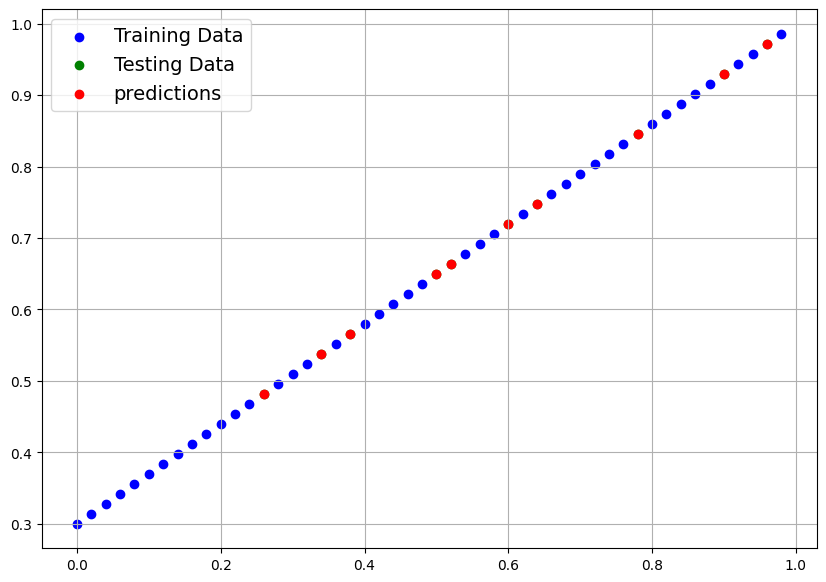

In [ ]:
## Epochs allow us to set the number of training loops the model goesthrough to improve predictions
# This is a hyperparameter that we have set ourselves and is not part of the model
epochs= 4000 
 # In practice, this value might be quite high, but its the number of epochs required for convergence for this data
 # Convergence means the training loss and the test/prediction loss values are quite close to each other.
 # We aim for convergence when teaining ML models

## We can save the loss values in order to visualize how the algorithm decreases the loss function
epoch_count= []
train_loss_values= []
test_loss_values= []

## loop through the data (performing the above steps)
for epoch in range(epochs):
    
    ## Set the model in training mode
    model_0.train() 

    # Forward pass
    y_train_pred= model_0.forward(X_train)

    # Loss function
    training_loss= loss_fn(y_train_pred, y_train)

    # Optimizer zero grad
    optimizer.zero_grad()
     # This step resets all gradients to zero before computing new ones
     # By default, PyTorch accumulates gradients
     # this means if they are not cleared, new gradients get added on top of the previous loop's gradients thereby corrupting them

    # Perform backpropagation on the loss wrt to model parameters
    training_loss.backward()
     # Here the gradients are computed via partial derivative of the loss wrt to the model parameters (weights and biases)

    # Perform gradient descent 
    optimizer.step()
     # The gradients computed in the previous step are used to update the parameters via gradient descent
    
    
    ## Testing mode
    # This turns off various settings in the model not needed for evaluation (eg- Dropout, Batch normalization)
    model_0.eval()
    # Turn off gradient tracking as well
    with torch.inference_mode():
        # Do the forward pass in testing mode
        test_pred= model_0(X_test)

        # Compute the loss
        test_loss= loss_fn(test_pred, y_test)
         # Model validation whether we use the validation set to gauge how well the model predicts the data at each training phase

    # Print out model parameters(after training loop)
    if epoch % 10== 0:
        print(f'---' * 30)
        print(f'Epoch {epoch}')
        print(f'Training Loss: {training_loss}')
        print(f'Testing Loss: {test_loss}')
        print(f'{model_0.state_dict()}')
        
        # Save loss values
        epoch_count.append(epoch)
        train_loss_values.append(training_loss)
        test_loss_values.append(test_loss)


## At the end of the training process, we plot the predicitons against the actual data
plot_predictions(predictions= test_pred)

The full picture training loop is as below:

```python
        ┌─────────────────────────────────────────────────────┐
                                                              │
X_train ──► [forward pass] ──► y_test ──► [loss_fn] ──► loss   │
                                                        │     │
                               weights ◄── [.step()]  ◄─┤     │
                                                        │     │
                                .grad ◄── [.backward()]─┘      │
                                                              │
        └─────────────────────────────────────────────────────┘
                         repeat for N epochs

```

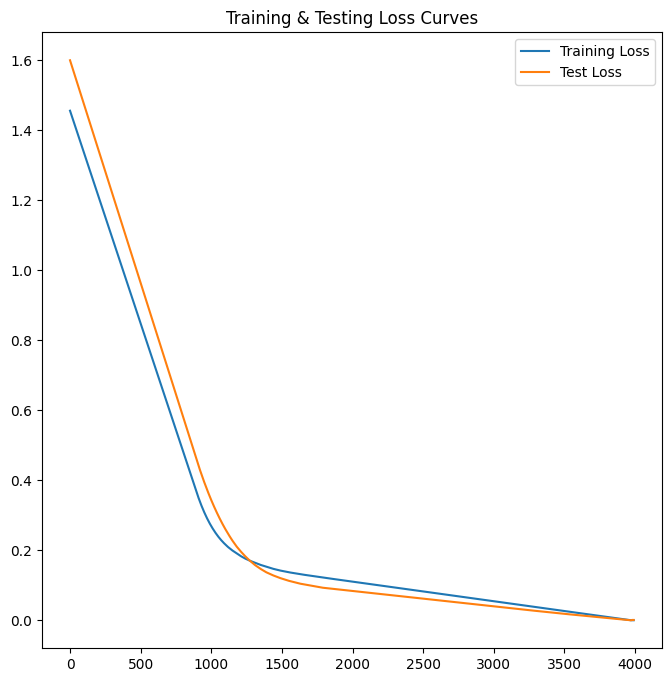

In [98]:
## Visualize the loss function
plt.figure(figsize= (8,8))
plt.plot(epoch_count, torch.tensor(train_loss_values).detach().numpy(), label= 'Training Loss')
plt.plot(epoch_count, torch.tensor(test_loss_values).numpy(), label= 'Test Loss')
 # We convert the tensor data into numpy arrays as Matplotlib cannot plot tensor data

plt.title('Training & Testing Loss Curves')
plt.legend()

##### Overfitting and Underfitting
Obtained from [Machine Learning Mastery](https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance/)

The above loss curve plot shows convergence has been achieved where, the training and validation loss very close to each other by the end of the training loop. This is a good sign that the model is learning (low training loss) and generalizing to unseen data well (low validation/test loss). We call this a *well-fitted model*. Below is another example of a well-fitted model as the training and validation loss are close to each other (with the validation loss being slightly greater than the training loss).

![Well-fitted model](https://towardsdatascience.com/wp-content/uploads/2021/02/1raMz_ZzCrow1e7d7q8II3w.jpeg)

An overfit model means that the model might be too complex to the point that it has also learned noise in the training data. As it has learned the training data too well, it does not generalize well to unseen data. It therefore causes much higher validation than training loss.

![Overfit model](https://towardsdatascience.com/wp-content/uploads/2021/02/1Hgi1mLu7i1KXSxjvyD0sSg.jpeg)

![Overfit model 2](https://machinelearningmastery.com/wp-content/uploads/2018/12/Example-of-Train-and-Validation-Learning-Curves-Showing-An-Overfit-Model-768x576.png)

An underfit model means that the model is too simple to the point that it has not learned anything from the training data. This can be due to the complexity of the dataset or the model requires more training, or the model is insufficient. Because of this it can cause an increase or stagnation in both the training and validation loss. The below shows an underfit model that is too simple for a complex dataset.

![Underfit Model](https://machinelearningmastery.com/wp-content/uploads/2019/02/Example-of-Training-Learning-Curve-Showing-An-Underfit-Model-That-Does-Not-Have-Sufficient-Capacity-768x576.png)

Below shows an underfit model that requires more training to generalize well to unseen data.
![Underfit Model 2](https://machinelearningmastery.com/wp-content/uploads/2018/12/Example-of-Training-Learning-Curve-Showing-An-Underfit-Model-That-Requires-Further-Training-768x576.png)

### Saving A Model
There are three main methods for saving and loading a PyTorch model:
- `torch.save()`- Allows one to save a PyTorch object in Python's `pickle` format. The `pickle` module implements a binary serialization protocol, which is a way to store Python objects in a binary format.
- `torch.load()`- Allows one to load a saved a PyTorch object
- `torch.nn.Module.load_state_dict()`- Allows one to load a saved a PyTorch dictionary. Recall our model parameters were stored in `model_0.state_dict()`

In [ ]:
## Savng the model
from pathlib import Path
 # The directory path

## Create the model's directory
model_path= Path('models') # Folder
model_path.mkdir(parents= True, # If working within a sub-folder of another folder
                 exist_ok= True) # If it already exists, it won't bring an error

## Create the model save path
model_name= 'simple_linear_regression_model_0.pth'
model_save_path= model_path/ model_name # This is the path to the model's file

## Save the parameters (model_state_dict)
print(f'Saving model to {model_save_path}')
torch.save(obj= model_0.state_dict(), f= model_save_path)

Saving model to models\simple_linear_regression_model_0.pth


When loading the model, since we saved the model's parameters (`state_dict()`) we have to instantiate a new instance of our model class (`LinearRegression()`)

In [ ]:
## Instantiate a new model
loaded_model_0= LinearRegressionModel()

# Initially, the instantiated model should have random parameters
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([-0.5581])), ('bias', tensor([0.6675]))])

In [101]:
## We can then load the saved parameters from the previous optimized model
loaded_model_0.load_state_dict(torch.load(f= model_save_path))
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.7000])), ('bias', tensor([0.2998]))])

In [102]:
## Make predictions with the loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_pred= loaded_model_0(X_test)

## Checking whether predictions for the loaded model are the same as the initial model
loaded_model_pred== test_pred


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])